# Math-on-paper with PyTorch

With PyTorch, creating a new network means creating a new class. Let's create this network:

<img src="https://lh3.googleusercontent.com/pw/AP1GczNDon-5hDy6V6PseH1hrcfWY0aMi_GMYULUe7Yqw8G9uPtIzYVUGeo8xeC_Nq7xCeSgTwKh3ilSV-mS3nZPDF5_-JBaQDPIKFMYn5GH9CFLtWMGeZXHMSBxC1F4aOusspn0GftJGrQ1qanGM2v7Lut2=w2009-h679-s-no-gm?authuser=0" width="1200">

## Import libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch  # imports PyTorch to create tensors and store values, such as weights and biases
import torch.nn as nn  # to make the weight and bias tensors part of the network
import torch.nn.functional as F  # to get the activation functions
from torch.optim import SGD


## Create the network based on the image above

In [21]:
class BasicNN(nn.Module):
    def __init__(self):
        super().__init__() # call init for the parent class (nn.Module)

        # ----- Create the network based on the image above -----
        # define a weight called w00 and initialize it with a scalar value of 1.7 parsed to a tensor, disable gradient optimization for this weight
        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        # define a bias
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        # another weight
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        # and so on
        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(-16.), requires_grad=False)

    # now we need to connect the parameters to the inputs, activation functions and the output
    def forward(self, input):
        # the top branch
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        # the bottom branch
        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        # final
        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias
        output = F.relu(input_to_final_relu)

        return output

## Forward pass and plot

In [22]:
# create a tensor with a length of 11 in the range of [0,1]
input_doses = torch.linspace(start=0, end=1, steps=11, dtype=torch.float64)

# naming 'model' is a standard convenience when coding with PyTorch
model = BasicNN()
output_values = model.forward(input_doses)
output_values

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0100, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000], dtype=torch.float64)

Text(0.5, 0, 'Dose')

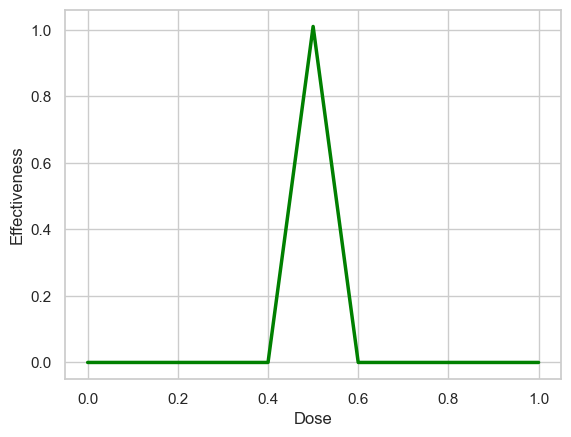

In [23]:
sns.set_theme(style='whitegrid')
sns.lineplot(x=input_doses,
             y=output_values,
             color='green',
             linewidth=2.5)

plt.ylabel('Effectiveness')
plt.xlabel('Dose')

## Training

Now, we copy the `basicNN` class and call it `basicNN_train` changing only one thing. In `__init__`, we set the bias to `0` and set its `requires_grad` to True. We want to train this network to adjust it back to `-16` itself.
```python
self.final_bias = nn.Parameter(torch.tensor(0.), requires_grad=True)
```

In [25]:
class BasicNN_train(nn.Module):
    def __init__(self):
        super().__init__() # call init for the parent class (nn.Module)

        # ----- Create the network based on the image above -----
        # define a weight called w00 and initialize it with a scalar value of 1.7 parsed to a tensor, disable gradient optimization for this weight
        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        # define a bias
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        # another weight
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        # and so on
        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(0.), requires_grad=True)

    # now we need to connect the parameters to the inputs, activation functions and the output
    def forward(self, input):
        # the top branch
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        # the bottom branch
        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        # final
        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias
        output = F.relu(input_to_final_relu)

        return output

In [ ]:
model = BasicNN_train()
output_values = model(input_doses)
output_values

tensor([ 0.0000,  3.4020,  6.8040, 10.2060, 13.6080, 17.0100, 13.4760,  9.9420,
         6.4080,  2.8740,  0.0000], dtype=torch.float64,
       grad_fn=<ReluBackward0>)

Text(0.5, 0, 'Dose')

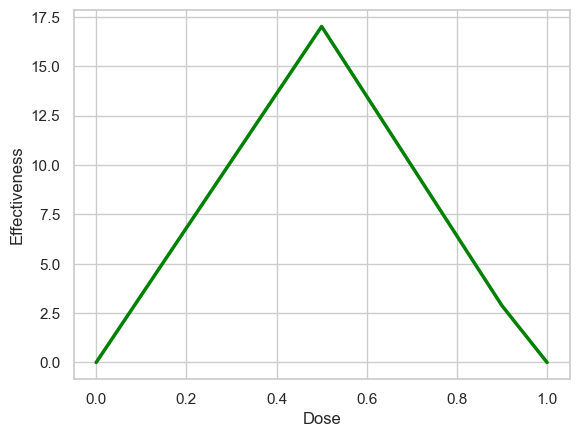

In [35]:
sns.set_theme(style='whitegrid')
sns.lineplot(x=input_doses,
             y=output_values.detach(), # detach() creates a new tensor with no gradients in it because seaborn doesn't know what to do with gradients
             color='green',
             linewidth=2.5)

plt.ylabel('Effectiveness')
plt.xlabel('Dose')

## Training

In [34]:
# input and target
inputs = torch.tensor([0., 0.5, 1.])
labels = torch.tensor([0., 1., 0.])

# optimizer that will optimize every single parameter with `requires_grad=True`
optimizer = SGD(model.parameters(), lr=0.1)
print(f"Final bias before optimization: {model.final_bias.data!s}\n") # "!s" converts the tensor to str

# pass the data through 100 times
for ep in range(100):
    total_loss = 0  # measure the error

    # loop through each data point
    for i in range(len(inputs)):
        # input and target for the current data point
        input_i = inputs[i]
        label_i = labels[i]

        # forward pass
        output_i = model(input_i)

        # error (MSE)
        loss = (output_i - label_i)**2

        # calculate the derivative of the loss function
        # with respect to the parameters we want to optimize
        # in this case, it is dL/db_final = d(MSE)/db_final
        # It also accumulates each iteration: d(MSE_0)/db_final + d(MSE_1)/db_final + ... d(MSE_i)/db_final
        loss.backward()

        total_loss+=float(loss)

    # early stopping
    # if the loss is small enough, stop and quit
    if (total_loss < 0.0001):
        print(f"Num steps: {ep}")
        break

    # if the loss is still significant, update the parameters
    optimizer.step()
    # reset the accumulated derivatives for the new epoch to start clean
    optimizer.zero_grad()

    print(f"Step: {ep}. Final bias: {model.final_bias.data!s}")

Final bias before optimization: tensor(-16.0019)

Num steps: 0
